# **UTP Kecerdasan Artifisial Lanjut 2026**

Nama: Hassan Nashrallah

NIM: 245150200111025

Kelas: F

---
## **Peraturan UTP KAL 2026**

1. Bergabung ke Google Meet yang telah disediakan dan oncam selama UTP berlangsung
2. Hadir di Google Meet tepat waktu, tidak ada tambahan waktu apabila terlambat
3. **Dilarang menggunakan bantuan AI** (ChatGPT, Claude, Gemini, dan model AI lainnya)
4. **Dilarang menggunakan library** selain yang telah ditentukan:
   * pandas
   * numpy
   * matplotlib
   * seaborn
   * sklearn.model_selection (train_test_split only)
   * sklearn.utils (shuffle only)
   * sklearn.preprocessing
   * sklearn.metrics
   * itertools
5. **Dilarang mencontek atau bekerja sama** dengan mahasiswa lain
6. **Waktu pengerjaan: 120 menit**
7. Semua kode harus dapat dijalankan tanpa error untuk mendapatkan nilai penuh
8. Upload file notebook (.ipynb) ke Google Classroom sebelum waktu berakhir
9. Kode jawaban harus ditulis pada template yang disediakan
10. Diharapkan untuk bergabung dalam Google Meet yang disediakan asisten praktikum dan menyalakan kamera selama UTP berlangsung

**Pelanggaran terhadap peraturan di atas dapat mengakibatkan pengurangan nilai hingga nilai 0.**

---

## Soal
### 🐱 **Survei Kucing Dunia: Siapa Ras Kucingmu?** 🐱

Sebuah organisasi penelitian internasional bernama **Global Cat Behaviour Institute (GCBI)** menjalankan survei daring selama dua tahun kepada para pemilik kucing di seluruh dunia. Pemilik kucing dari berbagai negara diminta mengisi formulir yang mencakup data lengkap tentang kucing mereka: ras, usia, jenis kelamin, warna bulu, pola bulu, warna mata, berat badan, panjang tubuh, kebiasaan tidur, waktu bermain bersama pemilik, apakah diperbolehkan keluar rumah, jenis makanan favorit, serta lokasi geografis pemilik.

Sayangnya, karena formulir diisi secara mandiri oleh ribuan responden dari latar belakang berbeda, data yang terkumpul jauh dari sempurna. Banyak responden salah mengeja nama ras kucingnya, mengisi kolom dengan teks bebas yang tidak relevan, melewatkan beberapa kolom, bahkan ada yang memasukkan angka yang jelas tidak masuk akal — seperti kucing yang tidur 30 jam sehari.

GCBI kini ingin membangun model klasifikasi untuk **memprediksi ras kucing** berdasarkan karakteristik fisik dan kebiasaan hidupnya, sehingga data survei masa depan dapat diverifikasi otomatis.

---

![Cat](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExdTBnMWc2cnlvd2dpNTZsZmI4cDJnYmZveTh2OXIzbjVwb21wbjhsNSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/vPzbDN4rBxuvtpSpzF/giphy.gif "cat")

---

### Tugas Kalian

Sebagai data scientist yang ditugaskan GCBI, tugas kalian adalah:

1. **Membersihkan data** dari segala masalah seperti *missing values*, *outliers*, ejaan yang salah, dan nilai yang tidak valid.
2. **Melakukan EDA**: temukan pola dan distribusi dalam data mentah sebelum dibersihkan. Apakah ada ras tertentu yang mendominasi? Adakah perbedaan karakteristik antar ras?
3. **Melatih model SVM** dari nol (tanpa menggunakan `sklearn.svm`) untuk mengklasifikasikan ras kucing berdasarkan atribut yang tersedia.
4. **Mengevaluasi performa model** menggunakan accuracy, precision, recall, F1-Score, dan confusion matrix.

# 1. Load Dataset

In [ ]:
# from google.colab import files
# uploaded = files.upload()

Saving cat_breeds_dirty.csv to cat_breeds_dirty.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
file = r"C:\Users\hassa\OneDrive\Dokumen\praktikumz\kal-praktikum\data\cat_breeds_dirty.csv"
df = pd.read_csv(file, sep=";", encoding="utf-8-sig")

# 2. Exploratory Data Analysis

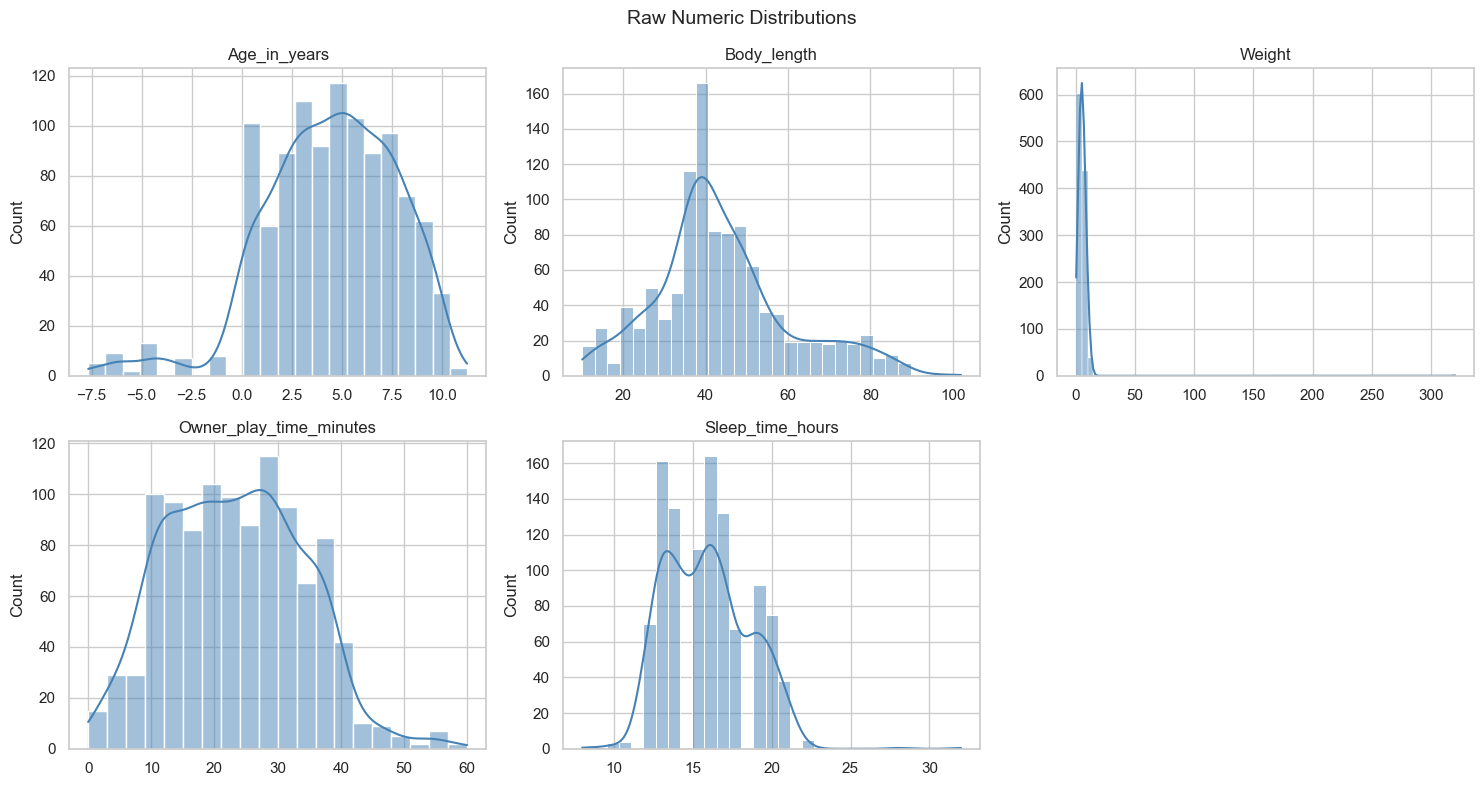

In [2]:
num_cols = ['Age_in_years', 'Body_length', 'Weight', 'Owner_play_time_minutes', 'Sleep_time_hours']
_fig, _axes = plt.subplots(2, 3, figsize=(15, 8))
_axes = _axes.flatten()
for _i, _col in enumerate(num_cols):
    sns.histplot(df[_col].dropna(), kde=True, ax=_axes[_i], color='steelblue')
    _axes[_i].set_title(_col)
    _axes[_i].set_xlabel('')
_axes[-1].set_visible(False)
plt.suptitle('Raw Numeric Distributions', fontsize=14)
plt.tight_layout()
plt.show()

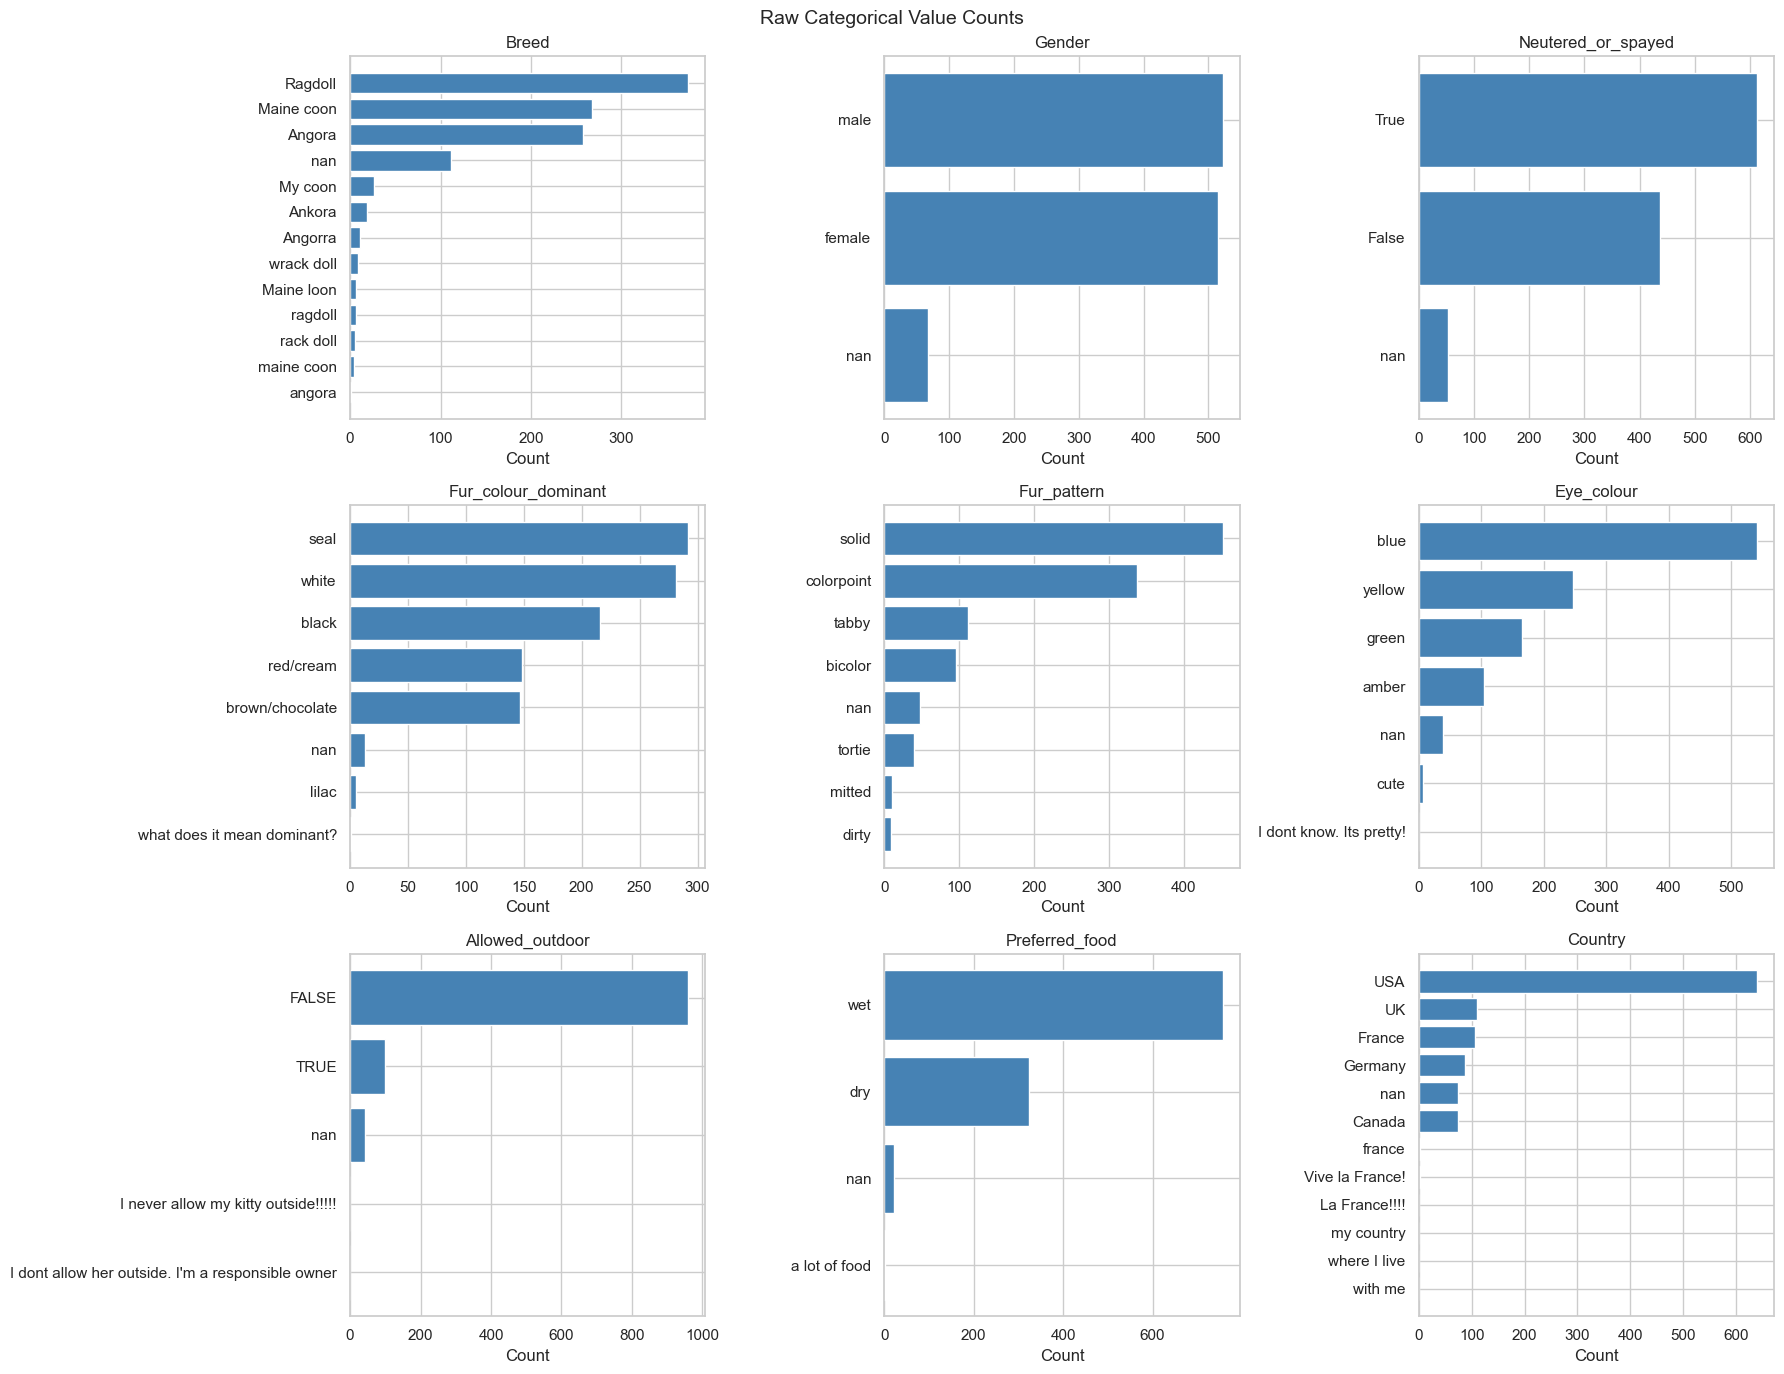

In [3]:
cat_cols = ['Breed', 'Gender', 'Neutered_or_spayed', 'Fur_colour_dominant', 'Fur_pattern', 'Eye_colour', 'Allowed_outdoor', 'Preferred_food', 'Country']
_fig, _axes = plt.subplots(3, 3, figsize=(18, 14))
_axes = _axes.flatten()
for _i, _col in enumerate(cat_cols):
    counts = df[_col].value_counts(dropna=False)
    labels = [str(v) for v in counts.index]
    _axes[_i].barh(labels, counts.values, color='steelblue')
    _axes[_i].invert_yaxis()
    _axes[_i].set_title(_col)
    _axes[_i].set_xlabel('Count')
plt.suptitle('Raw Categorical Value Counts', fontsize=14)
plt.tight_layout()
plt.show()

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3.0,female,False,19.0,2.0,white,solid,blue,FALSE,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.33,4.0,male,False,19.0,2.5,white,solid,blue,FALSE,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.50,NaN,NaN,False,20.0,2.8,what does it mean dominant?,solid,green,I never allow my kitty outside!!!!!,wet,41.0,11.0,France,44.837789,-0.579180
3,Ankora,0.50,NaN,NaN,False,21.0,3.0,white,dirty,blue,FALSE,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.50,NaN,NaN,NaN,21.0,3.0,red/cream,tabby,green,FALSE,wet,51.0,10.0,france,48.864716,2.349014


Shape: (1103, 17)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    991 non-null    object 
 1   Age_in_years             1072 non-null   float64
 2   Age_in_months            1066 non-null   float64
 3   Gender                   1036 non-null   object 
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1077 non-null   float64
 6   Weight                   1077 non-null   float64
 7   Fur_colour_dominant      1090 non-null   object 
 8   Fur_pattern              1055 non-null   object 
 9   Eye_colour               1064 non-null   object 
 10  Allowed_outdoor          1060 non-null   object 
 11  Preferred_food           1082 non-null   object 
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14 

,missing_count
Breed,112
Country,75
Gender,67
Latitude,61
Longitude,61
Neutered_or_spayed,53
Fur_pattern,48
Allowed_outdoor,43
Sleep_time_hours,41
Eye_colour,39



Distribusi target mentah (Breed):


,count
Breed,
Ragdoll,374
Maine coon,268
Angora,258
NaN,112
My coon,27
Ankora,19
Angorra,11
wrack doll,9
Maine loon,7



Ringkasan statistik numerik mentah:


,count,mean,std,min,25%,50%,75%,max
Age_in_years,1072.0,4.460752,3.262166,-7.666667,2.33,4.75,6.92,11.25
Age_in_months,1066.0,53.778612,39.355581,-92.000000,28.00,57.00,84.00,135.00
Body_length,1077.0,43.903435,16.240466,10.000000,35.00,41.00,51.00,102.00
Weight,1077.0,5.740901,9.853438,0.500000,3.90,5.00,7.00,320.00
Owner_play_time_minutes,1082.0,23.176525,10.815298,0.000000,15.00,23.00,31.00,60.00
Sleep_time_hours,1062.0,15.898305,2.656775,8.000000,14.00,16.00,18.00,32.00



Contoh anomali numerik:
Age_in_years < 0: 44
Age_in_months < 0: 44
Sleep_time_hours > 24: 2
Weight > 20: 1


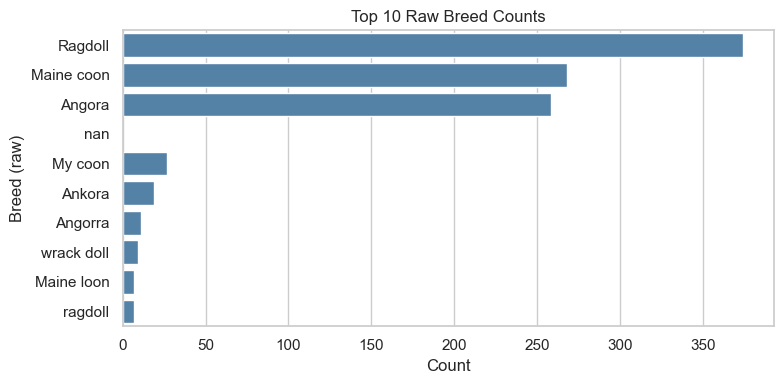

In [5]:
# lanjutkan EDA
display(df.head())
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nMissing value per kolom:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDistribusi target mentah (Breed):")
display(df['Breed'].value_counts(dropna=False).head(15).to_frame('count'))

num_cols_check = ['Age_in_years', 'Age_in_months', 'Body_length', 'Weight', 'Owner_play_time_minutes', 'Sleep_time_hours']
print("\nRingkasan statistik numerik mentah:")
display(df[num_cols_check].describe().T)

print("\nContoh anomali numerik:")
print("Age_in_years < 0:", (pd.to_numeric(df['Age_in_years'], errors='coerce') < 0).sum())
print("Age_in_months < 0:", (pd.to_numeric(df['Age_in_months'], errors='coerce') < 0).sum())
print("Sleep_time_hours > 24:", (pd.to_numeric(df['Sleep_time_hours'], errors='coerce') > 24).sum())
print("Weight > 20:", (pd.to_numeric(df['Weight'], errors='coerce') > 20).sum())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='Breed', order=df['Breed'].value_counts(dropna=False).head(10).index, color='steelblue')
plt.title('Top 10 Raw Breed Counts')
plt.xlabel('Count')
plt.ylabel('Breed (raw)')
plt.tight_layout()
plt.show()

# 3. Data Cleaning

In [6]:
df_clean = df.copy()

def norm_text(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip().lower()
    return np.nan if v == '' else v

for c in df_clean.columns:
    if df_clean[c].dtype == object:
        df_clean[c] = df_clean[c].apply(norm_text)

# Standarisasi label target ras (menggabungkan typo ke 3 kelas utama)
def clean_breed(v):
    if pd.isna(v):
        return np.nan
    if ('ang' in v) or ('ankor' in v):
        return 'angora'
    if ('coon' in v) or ('coon' in v.replace(' ', '')):
        return 'maine coon'
    if ('rag' in v) or ('rack' in v) or ('wrack' in v):
        return 'ragdoll'
    return np.nan

df_clean['Breed'] = df_clean['Breed'].apply(clean_breed)

# Normalisasi kategori biner
bool_map = {
    'true': 'true',
    'false': 'false',
    'i never allow my kitty outside!!!!!': 'false',
    'i dont allow her outside, because i am afraid she will become friend with stranger people and leave me forever': 'false'
}
df_clean['Gender'] = df_clean['Gender'].replace({'male': 'male', 'female': 'female'})
df_clean['Neutered_or_spayed'] = df_clean['Neutered_or_spayed'].replace(bool_map)
df_clean['Allowed_outdoor'] = df_clean['Allowed_outdoor'].replace(bool_map)

# Bersihkan kategori noisy
df_clean['Preferred_food'] = df_clean['Preferred_food'].replace({'a lot of food': np.nan})
df_clean['Fur_pattern'] = df_clean['Fur_pattern'].replace({'dirty': np.nan})
df_clean['Eye_colour'] = df_clean['Eye_colour'].replace({'cute': np.nan, 'i dont know. its pretty!': np.nan})
df_clean['Country'] = df_clean['Country'].replace({
    'la france!!!!': 'france',
    'vive la france!': 'france',
    'my country': np.nan,
    'where i live': np.nan,
    'with me': np.nan
})

# Konversi numerik
num_cols = ['Age_in_years', 'Age_in_months', 'Body_length', 'Weight', 'Owner_play_time_minutes', 'Sleep_time_hours', 'Latitude', 'Longitude']
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

# Rekonsiliasi umur tahun-bulan
df_clean.loc[df_clean['Age_in_years'].isna() & df_clean['Age_in_months'].notna(), 'Age_in_years'] = df_clean['Age_in_months'] / 12.0
df_clean.loc[df_clean['Age_in_months'].isna() & df_clean['Age_in_years'].notna(), 'Age_in_months'] = (df_clean['Age_in_years'] * 12.0).round()

# Tandai nilai tidak valid menjadi NaN
df_clean.loc[(df_clean['Age_in_years'] < 0) | (df_clean['Age_in_years'] > 25), 'Age_in_years'] = np.nan
df_clean.loc[(df_clean['Age_in_months'] < 0) | (df_clean['Age_in_months'] > 300), 'Age_in_months'] = np.nan
df_clean.loc[(df_clean['Body_length'] < 10) | (df_clean['Body_length'] > 120), 'Body_length'] = np.nan
df_clean.loc[(df_clean['Weight'] < 0.8) | (df_clean['Weight'] > 15), 'Weight'] = np.nan
df_clean.loc[(df_clean['Owner_play_time_minutes'] < 0) | (df_clean['Owner_play_time_minutes'] > 180), 'Owner_play_time_minutes'] = np.nan
df_clean.loc[(df_clean['Sleep_time_hours'] < 0) | (df_clean['Sleep_time_hours'] > 24), 'Sleep_time_hours'] = np.nan

# Imputasi numerik dengan median
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Imputasi kategorikal dengan modus
cat_cols = ['Gender', 'Neutered_or_spayed', 'Fur_colour_dominant', 'Fur_pattern', 'Eye_colour', 'Allowed_outdoor', 'Preferred_food', 'Country']
for c in cat_cols:
    mode_val = df_clean[c].mode(dropna=True)
    if len(mode_val) > 0:
        df_clean[c] = df_clean[c].fillna(mode_val.iloc[0])

# Hapus baris tanpa target
before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['Breed']).copy()
after_rows = len(df_clean)

print('Rows sebelum drop target kosong:', before_rows)
print('Rows sesudah drop target kosong:', after_rows)
print('\nDistribusi target bersih:')
display(df_clean['Breed'].value_counts().to_frame('count'))
print('\nSisa missing values (harus 0 untuk fitur yang dipakai model):')
display(df_clean[['Breed'] + num_cols + cat_cols].isna().sum().to_frame('missing_count'))

Rows sebelum drop target kosong: 1103
Rows sesudah drop target kosong: 984

Distribusi target bersih:


,count
Breed,
ragdoll,396
maine coon,299
angora,289



Sisa missing values (harus 0 untuk fitur yang dipakai model):


,missing_count
Breed,0
Age_in_years,0
Age_in_months,0
Body_length,0
Weight,0
Owner_play_time_minutes,0
Sleep_time_hours,0
Latitude,0
Longitude,0
Gender,0


# 4. SVM

Accuracy : 0.9543
Precision: 0.9552
Recall   : 0.95
F1-score : 0.949


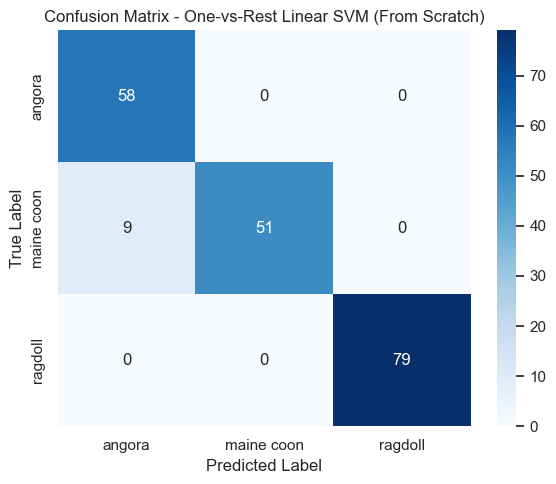


Classification Report:
              precision    recall  f1-score   support

      angora       0.87      1.00      0.93        58
  maine coon       1.00      0.85      0.92        60
     ragdoll       1.00      1.00      1.00        79

    accuracy                           0.95       197
   macro avg       0.96      0.95      0.95       197
weighted avg       0.96      0.95      0.95       197



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Siapkan fitur
feature_cols_num = ['Age_in_years', 'Body_length', 'Weight', 'Owner_play_time_minutes', 'Sleep_time_hours', 'Latitude', 'Longitude']
feature_cols_cat = ['Gender', 'Neutered_or_spayed', 'Fur_colour_dominant', 'Fur_pattern', 'Eye_colour', 'Allowed_outdoor', 'Preferred_food', 'Country']

X = df_clean[feature_cols_num + feature_cols_cat].copy()
X = pd.get_dummies(X, columns=feature_cols_cat, drop_first=False)
y = df_clean['Breed'].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class BinaryLinearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1200):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[idx] * x_i)
                    self.b -= self.lr * (-y[idx])

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

class OneVsRestSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1200):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.models = {}
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for c in self.classes_:
            y_binary = np.where(y == c, 1, -1)
            clf = BinaryLinearSVM(lr=self.lr, lambda_param=self.lambda_param, n_iters=self.n_iters)
            clf.fit(X, y_binary)
            self.models[c] = clf

    def predict(self, X):
        scores = []
        for c in self.classes_:
            s = self.models[c].decision_function(X)
            scores.append(s)
        scores = np.vstack(scores).T
        return self.classes_[np.argmax(scores, axis=1)]

ovr_svm = OneVsRestSVM(lr=0.001, lambda_param=0.01, n_iters=1200)
ovr_svm.fit(X_train, y_train)
y_pred = ovr_svm.predict(X_test)

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4))
print('Recall   :', round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4))
print('F1-score :', round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))

cm = confusion_matrix(y_test, y_pred)
class_names = label_encoder.inverse_transform(np.unique(y_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - One-vs-Rest Linear SVM (From Scratch)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Pertanyaan

1. Jelaskan pendekatan yang Anda gunakan untuk menangani nilai yang hilang pada kolom numerik dalam dataset ini. Mengapa Anda memilih pendekatan tersebut dibandingkan alternatif lainnya?

2. Dataset ini memiliki tiga kelas target. Jelaskan pendekatan yang Anda gunakan untuk mengimplementasikan SVM pada klasifikasi multikelas ini, dan bagaimana cara kerjanya dalam menentukan prediksi akhir untuk setiap sampel.

3. Berdasarkan confusion matrix yang dihasilkan, jelaskan performa model Anda dalam mengklasifikasikan setiap ras kucing. Apakah ada ras yang lebih sulit diprediksi dibanding yang lain? Berikan analisis Anda.